In [1]:
# CELDA 1 — Setup
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Estética de los gráficos
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Paths del proyecto
PROJECT_PATH = '/content/drive/MyDrive/HortifrutCostosImport'
PROCESSED_PATH = f'{PROJECT_PATH}/data/processed'
FIGURES_PATH = f'{PROJECT_PATH}/reports/figures'
os.makedirs(FIGURES_PATH, exist_ok=True)

# Cargar el dataset unificado que generamos antes
df = pd.read_parquet(f'{PROCESSED_PATH}/dataset_unificado.parquet')
print(f"Dataset cargado: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Operaciones únicas: {df['Nro. Ope.'].nunique():,}")
print(f"Campañas: {sorted(df['Campaña'].dropna().unique().tolist())}")

Mounted at /content/drive
Dataset cargado: 14,705 filas × 53 columnas
Operaciones únicas: 1,252
Campañas: [2020, 2021, 2022, 2023, 2024, 2025, 2026]


In [2]:
# CELDA 2 — Vista panorámica del dataset
print(f"📊 Resumen general:")
print(f"  Filas:               {len(df):,}")
print(f"  Columnas:            {df.shape[1]}")
print(f"  Operaciones únicas:  {df['Nro. Ope.'].nunique():,}")
print(f"  Periodo:             {df['Campaña'].min()} - {df['Campaña'].max()}")
print(f"  Tamaño en memoria:   {df.memory_usage(deep=True).sum() / 1024**2:.1f} MB")

print(f"\n📁 Tipos de columnas:")
print(df.dtypes.value_counts().to_string())

print(f"\n👀 Primeras 3 filas:")
df.head(3)

📊 Resumen general:
  Filas:               14,705
  Columnas:            53
  Operaciones únicas:  1,252
  Periodo:             2020 - 2026
  Tamaño en memoria:   35.4 MB

📁 Tipos de columnas:
object            43
float64            7
datetime64[ns]     2
Int64              1

👀 Primeras 3 filas:


,Campaña,Nro. Ope.,Versión Nro. Ope.,OC,Importador/SOC,Área Usuaria,POL,Proveedor Principal,Producto,FACTURA,...,Modalidad (MODE Y TYPE),Incoterm,País de Origen (POL),POD (Puerto Destino),Fecha de Llegada (ETA),Fecha de Despacho,Delivery type,Final delivery,Proyecto,Concepto Canónico
0,2020,19-063H-173,2.0,4700001379,HORTIFRUT-TAL S.A.C.,Operaciones Agrícolas,RIGA,COMERCIAL PROJAR S.A.,Turba Blend 040,FRCLP-19-00588,...,None,None,None,None,NaT,NaT,None,None,None,FITOSANITARIOS_SENASA
1,2020,20-001-HPER,1.0,4700001496,HORTIFRUT-PERU S.A.C.,Cosecha,BARCELONA,CAMPAGNOLA IBERICA SL,Tijeras,951,...,SEA / LCL/LCL,CIF,None,BARCELONA,2020-01-03,NaT,None,CHAO,None,AGENCIAMIENTO_ADUANA
2,2020,20-001-HPER,1.0,4700001496,HORTIFRUT-PERU S.A.C.,Cosecha,BARCELONA,CAMPAGNOLA IBERICA SL,Tijeras,951,...,SEA / LCL/LCL,CIF,None,BARCELONA,2020-01-03,NaT,None,CHAO,None,TRANSPORTE_T1_CALLAO_LIMA


Top 20 columnas con más valores faltantes:
                   Columna           Tipo  # Nulos  % Nulos
               Unnamed: 38        float64    14705    100.0
           Peso Bruto (kg)        float64    13302     90.5
             Delivery type         object    11747     79.9
               Nro Liquid.         object     9808     66.7
  Fecha de Envío Provisión         object     9039     61.5
      País de Origen (POL)         object     7871     53.5
  Cantidad de Contenedores        float64     5489     37.3
                       Igv        float64     4814     32.7
      Fecha de Emisión Doc         object     4651     31.6
                   Country         object     3170     21.6
                    Market         object     3170     21.6
         Fecha de Despacho datetime64[ns]     3096     21.1
        Tipo de Contenedor         object     2783     18.9
                  Proyecto         object     1528     10.4
Cantidad de Bultos (BULKS)        float64      703      4

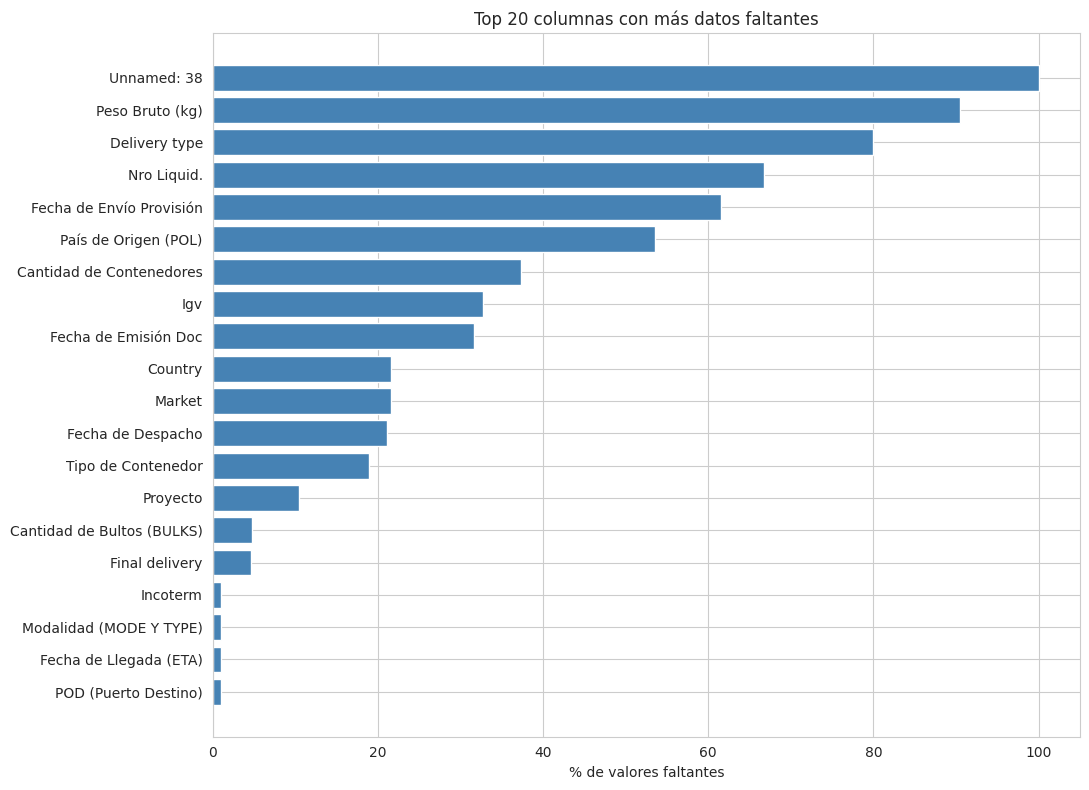

In [3]:
# CELDA 3 — Análisis de valores faltantes
nulos = pd.DataFrame({
    'Columna': df.columns,
    'Tipo':    df.dtypes.astype(str).values,
    '# Nulos': df.isna().sum().values,
    '% Nulos': (df.isna().sum() / len(df) * 100).round(1).values
})
nulos = nulos.sort_values('% Nulos', ascending=False).reset_index(drop=True)

print("Top 20 columnas con más valores faltantes:")
print(nulos.head(20).to_string(index=False))

# Gráfico de barras horizontales
plt.figure(figsize=(11, 8))
top_nulos = nulos[nulos['% Nulos'] > 0].head(20)
plt.barh(top_nulos['Columna'][::-1], top_nulos['% Nulos'][::-1], color='steelblue')
plt.xlabel('% de valores faltantes')
plt.title('Top 20 columnas con más datos faltantes')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/01_nulos_por_columna.png', dpi=100, bbox_inches='tight')
plt.show()

In [4]:
# CELDA 4 — Convertir USD y EUR a PEN
# Fuente: BCRP — promedios anuales de tipo de cambio
# https://estadisticas.bcrp.gob.pe/estadisticas/series/anuales/tipo-de-cambio

TC_USD_PEN = {
    2020: 3.495,
    2021: 3.880,
    2022: 3.834,
    2023: 3.742,
    2024: 3.753,
    2025: 3.700,   # estimación
    2026: 3.700,   # estimación
}
TC_EUR_PEN = {
    2020: 3.99,
    2021: 4.60,
    2022: 4.03,
    2023: 4.05,
    2024: 4.06,
    2025: 4.00,
    2026: 4.00,
}

def convertir_a_pen(monto, moneda, campaña):
    """Convierte un monto en su moneda original a PEN según el año de la campaña."""
    if pd.isna(monto) or pd.isna(moneda) or pd.isna(campaña):
        return np.nan
    campaña = int(campaña)
    if moneda == 'PEN':
        return monto
    elif moneda == 'USD':
        return monto * TC_USD_PEN.get(campaña, np.nan)
    elif moneda == 'EUR':
        return monto * TC_EUR_PEN.get(campaña, np.nan)
    return np.nan

# Limpiar la columna Importe Total (a veces viene como string con comas de miles)
df['Importe Total'] = pd.to_numeric(
    df['Importe Total'].astype(str).str.replace(',', '').str.strip(),
    errors='coerce'
)

# Aplicar la conversión fila por fila
df['Importe_Total_PEN'] = df.apply(
    lambda r: convertir_a_pen(r['Importe Total'], r['Moneda'], r['Campaña']),
    axis=1
)

print("Resumen del target en soles:")
print(df['Importe_Total_PEN'].describe().to_string())
print(f"\nFilas con valor válido en PEN: {df['Importe_Total_PEN'].notna().sum():,} / {len(df):,}")

Resumen del target en soles:
count    1.470500e+04
mean     7.944224e+03
std      3.217127e+04
min     -6.872400e+04
25%      2.970750e+02
50%      1.091500e+03
75%      4.162190e+03
max      1.142804e+06

Filas con valor válido en PEN: 14,705 / 14,705


📈 Estadísticas del target en soles:
  Mínimo:    S/     -68,724.00
  Mediana:   S/       1,091.50
  Promedio:  S/       7,944.22
  Máximo:    S/   1,142,803.56
  Total:     S/ 116,819,816.99

  Diferencia mediana vs promedio: 7.3x


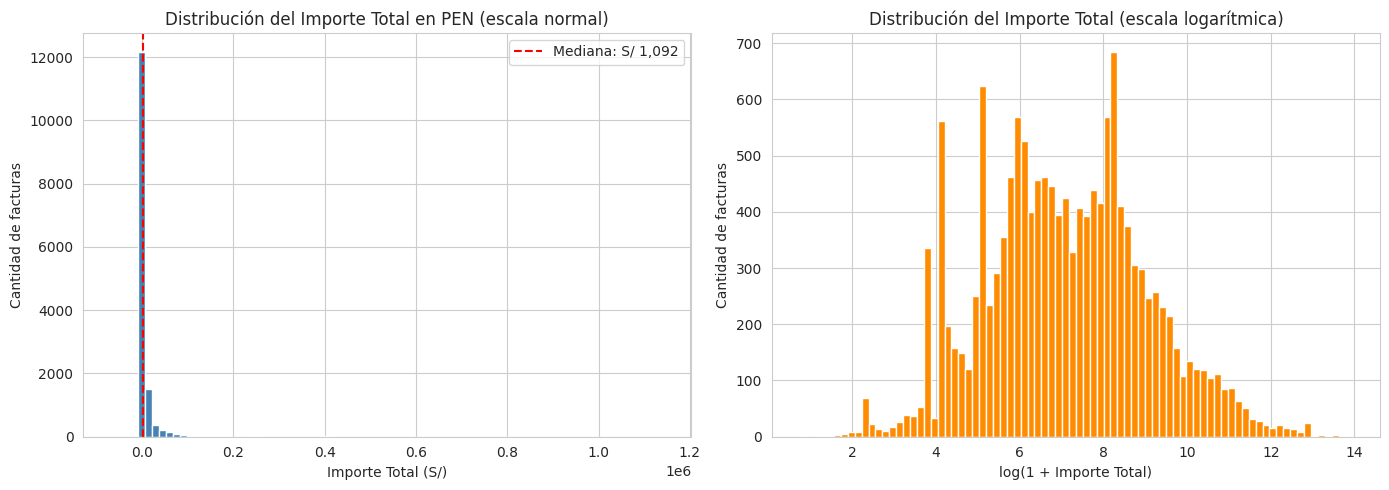

In [5]:
# CELDA 5 — Distribución del target
importe = df['Importe_Total_PEN'].dropna()
importe_pos = importe[importe > 0]  # para la escala log necesitamos solo positivos

print(f"📈 Estadísticas del target en soles:")
print(f"  Mínimo:    S/ {importe.min():>14,.2f}")
print(f"  Mediana:   S/ {importe.median():>14,.2f}")
print(f"  Promedio:  S/ {importe.mean():>14,.2f}")
print(f"  Máximo:    S/ {importe.max():>14,.2f}")
print(f"  Total:     S/ {importe.sum():>14,.2f}")
print(f"\n  Diferencia mediana vs promedio: {importe.mean()/importe.median():.1f}x")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: histograma en escala normal
axes[0].hist(importe, bins=80, color='steelblue', edgecolor='white')
axes[0].set_title('Distribución del Importe Total en PEN (escala normal)')
axes[0].set_xlabel('Importe Total (S/)')
axes[0].set_ylabel('Cantidad de facturas')
axes[0].axvline(importe.median(), color='red', linestyle='--',
                label=f'Mediana: S/ {importe.median():,.0f}')
axes[0].legend()

# Gráfico 2: histograma con transformación logarítmica
axes[1].hist(np.log1p(importe_pos), bins=80, color='darkorange', edgecolor='white')
axes[1].set_title('Distribución del Importe Total (escala logarítmica)')
axes[1].set_xlabel('log(1 + Importe Total)')
axes[1].set_ylabel('Cantidad de facturas')

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/02_distribucion_target.png', dpi=100, bbox_inches='tight')
plt.show()

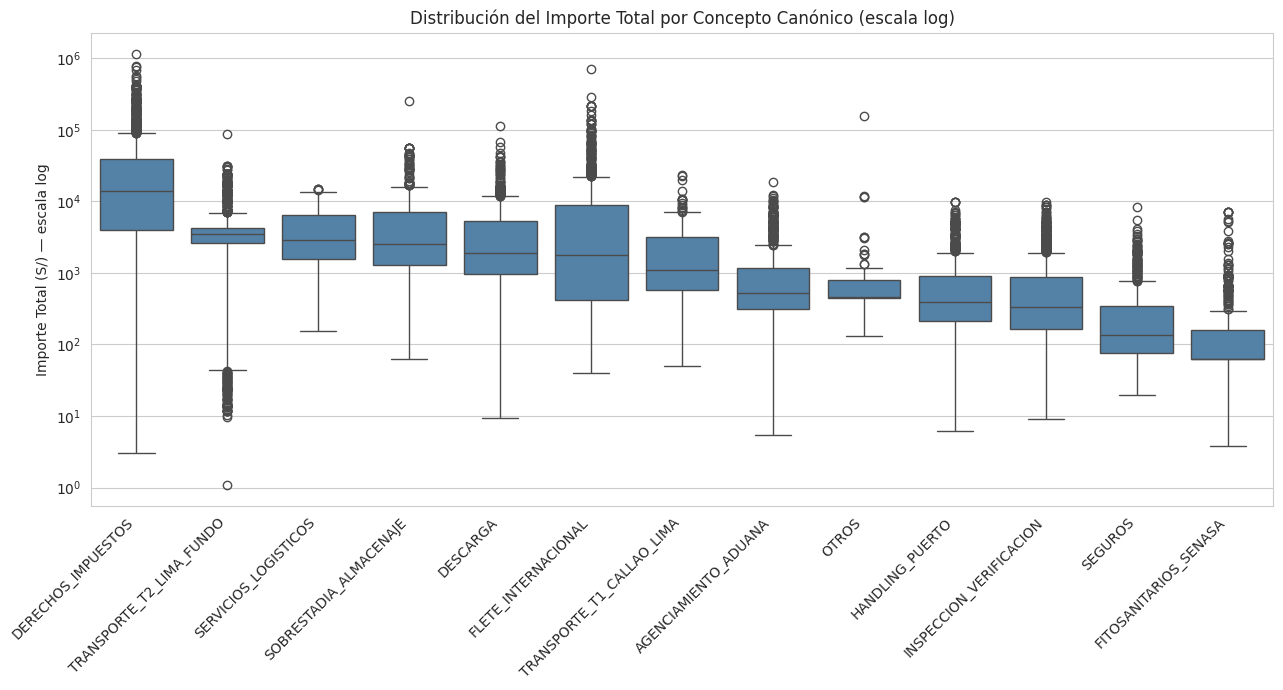

Resumen por Concepto Canónico (ordenado por mediana descendente):
                           # facturas  Mediana (S/)  Promedio (S/)  Desv. Estándar (S/)
Concepto Canónico                                                                      
DERECHOS_IMPUESTOS               2140       14036.0        36756.0              73404.0
TRANSPORTE_T2_LIMA_FUNDO         1536        3540.0         4446.0               4900.0
SERVICIOS_LOGISTICOS              587        2859.0         4168.0               3287.0
SOBRESTADIA_ALMACENAJE            472        2566.0         7550.0              15686.0
DESCARGA                         1724        1913.0         4025.0               6006.0
FLETE_INTERNACIONAL              1044        1761.0        11380.0              34311.0
TRANSPORTE_T1_CALLAO_LIMA         840        1086.0         2066.0               2220.0
AGENCIAMIENTO_ADUANA             1049         531.0         1237.0               1865.0
OTROS                              71         460.0   

In [6]:
# CELDA 6 — Distribución del target POR concepto canónico
data_plot = df[df['Importe_Total_PEN'] > 0].copy()  # filtramos negativos para el log

# Calcular mediana por concepto para ordenar las cajas
orden_conceptos = (
    data_plot.groupby('Concepto Canónico')['Importe_Total_PEN']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

# Crear figura
fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(
    data=data_plot,
    x='Concepto Canónico',
    y='Importe_Total_PEN',
    order=orden_conceptos,
    ax=ax,
    color='steelblue'
)
ax.set_yscale('log')   # escala logarítmica en Y para que se vea bien la variabilidad
ax.set_title('Distribución del Importe Total por Concepto Canónico (escala log)')
ax.set_ylabel('Importe Total (S/) — escala log')
ax.set_xlabel('')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/03_target_por_concepto.png', dpi=100, bbox_inches='tight')
plt.show()

# Tabla resumen complementaria
resumen = (
    data_plot.groupby('Concepto Canónico')['Importe_Total_PEN']
    .agg(['count', 'median', 'mean', 'std'])
    .round(0)
    .sort_values('median', ascending=False)
)
resumen.columns = ['# facturas', 'Mediana (S/)', 'Promedio (S/)', 'Desv. Estándar (S/)']
print("Resumen por Concepto Canónico (ordenado por mediana descendente):")
print(resumen.to_string())

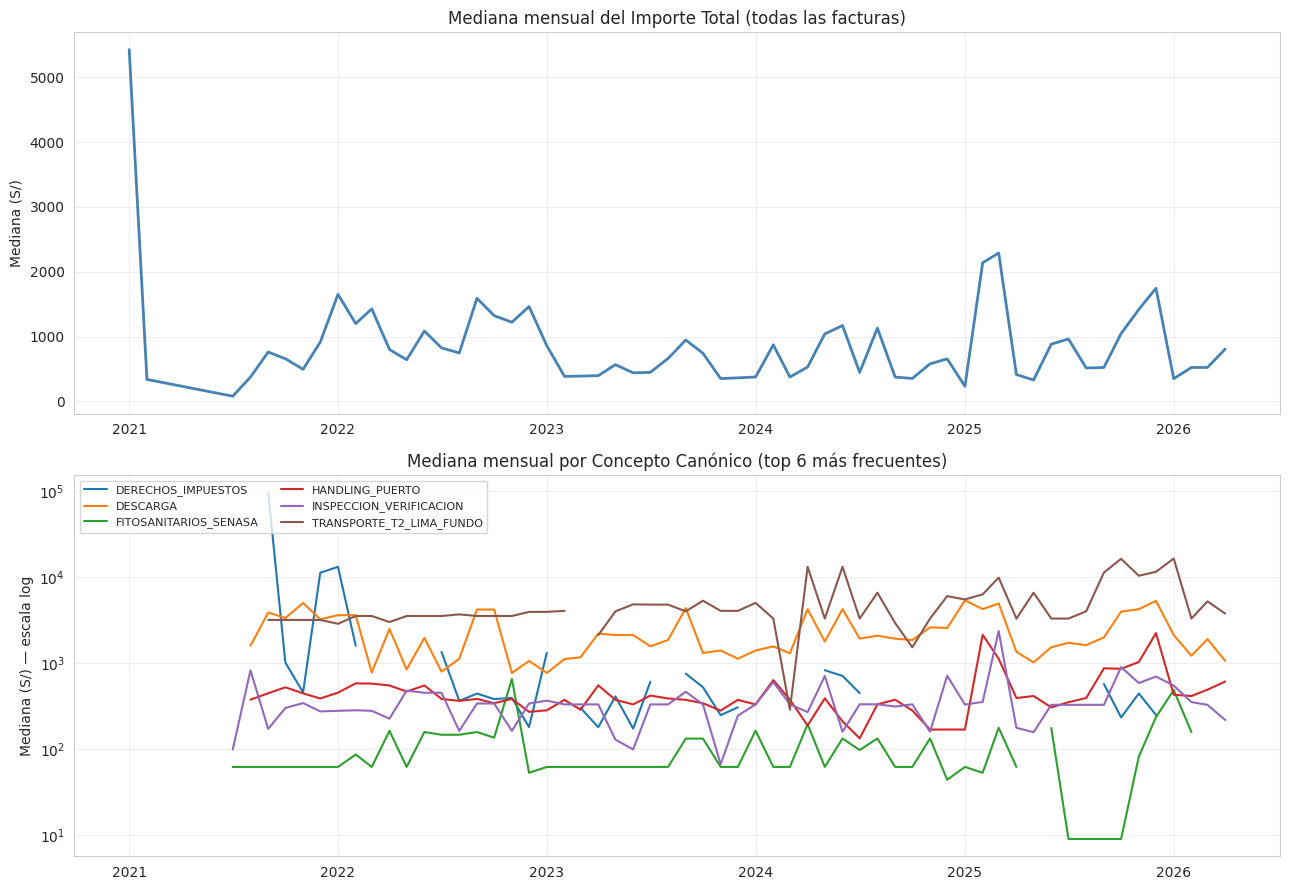

Periodo cubierto: 2021-01 → 2026-04
Meses con datos: 60


In [7]:
# CELDA 7 — Evolución temporal del target
# Asegurar que tenemos una columna de fecha — usamos 'Fecha de Emisión Doc' si existe
fecha_col = 'Fecha de Emisión Doc'
df[fecha_col] = pd.to_datetime(df[fecha_col], errors='coerce', dayfirst=True)

# Filtramos a registros con fecha y monto positivo
temporal = df[(df['Importe_Total_PEN'] > 0) & df[fecha_col].notna()].copy()
temporal['Año-Mes'] = temporal[fecha_col].dt.to_period('M').dt.to_timestamp()

# Mediana mensual del target
mediana_mensual = temporal.groupby('Año-Mes')['Importe_Total_PEN'].median()

# Mediana mensual por concepto canónico (top 6 más frecuentes para no saturar el gráfico)
top_conceptos = (
    df['Concepto Canónico'].value_counts().head(6).index.tolist()
)
temporal_top = temporal[temporal['Concepto Canónico'].isin(top_conceptos)]
mediana_mes_concepto = (
    temporal_top.groupby(['Año-Mes', 'Concepto Canónico'])['Importe_Total_PEN']
    .median().unstack()
)

# Gráfico
fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Panel A: agregado
axes[0].plot(mediana_mensual.index, mediana_mensual.values, color='steelblue', linewidth=2)
axes[0].set_title('Mediana mensual del Importe Total (todas las facturas)')
axes[0].set_ylabel('Mediana (S/)')
axes[0].grid(alpha=0.3)

# Panel B: top 6 conceptos
for col in mediana_mes_concepto.columns:
    axes[1].plot(mediana_mes_concepto.index, mediana_mes_concepto[col], label=col, linewidth=1.5)
axes[1].set_title('Mediana mensual por Concepto Canónico (top 6 más frecuentes)')
axes[1].set_ylabel('Mediana (S/) — escala log')
axes[1].set_yscale('log')
axes[1].legend(loc='upper left', fontsize=8, ncol=2)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/04_evolucion_temporal.png', dpi=100, bbox_inches='tight')
plt.show()

print(f"Periodo cubierto: {mediana_mensual.index.min().strftime('%Y-%m')} → {mediana_mensual.index.max().strftime('%Y-%m')}")
print(f"Meses con datos: {len(mediana_mensual)}")

Cardinalidad de variables categóricas (de más a menos diversa):
                   Columna  Valores únicos  % Nulos
              Nro. de Doc.           11854      0.0
           Monto Total USD            5021      0.0
               Monto Final            4784      0.0
                 Provisión            4781      0.1
               Nro Liquid.            1710     66.7
                  BL / AWB            1259      0.3
                 Nro. Ope.            1252      0.0
                   FACTURA            1181      0.9
                       OC2            1133      0.0
                        OC            1133      0.0
Fecha de Envío Liquidación             664      0.2
                  Producto             379      0.2
  Fecha de Envío Provisión             246     61.5
                 Proveedor             175      0.0
       Proveedor Principal             164      0.2
                       POL              97      0.4
                  Concepto              78      0.0


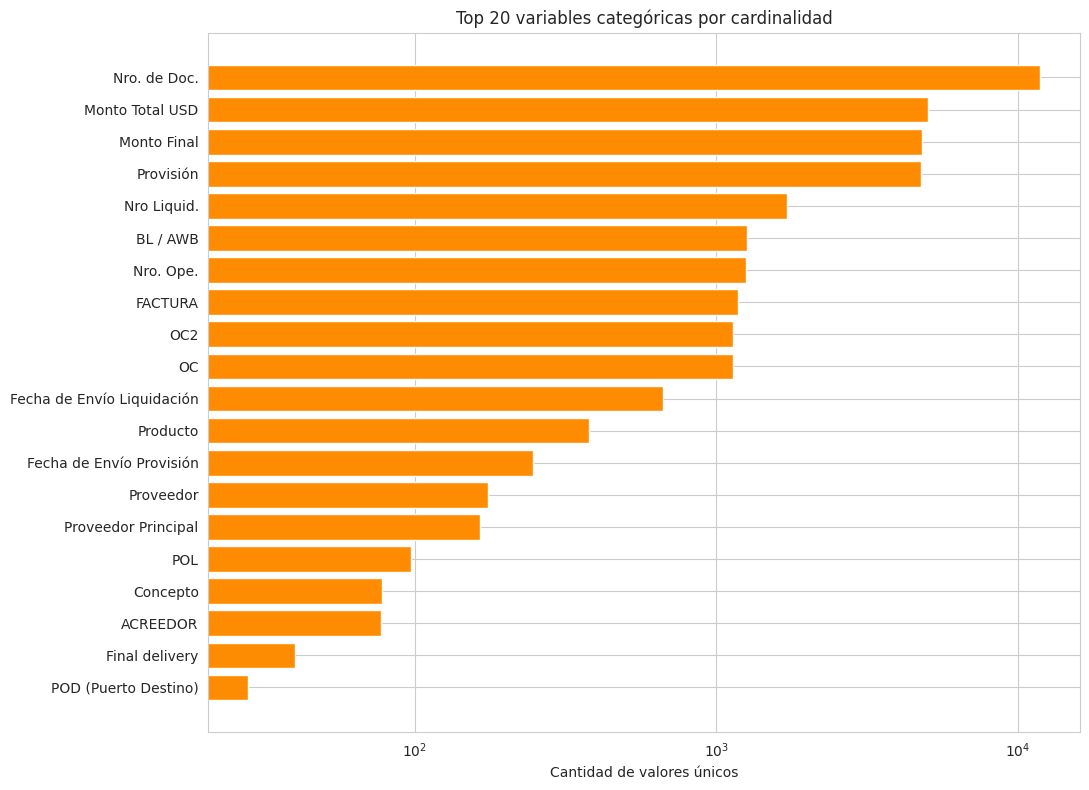

In [9]:
# CELDA 8 — Cardinalidad de variables categóricas
# Identificar columnas tipo texto (categóricas)
cat_cols = df.select_dtypes(include='object').columns.tolist()

# Calcular cardinalidad
cardinalidad = pd.DataFrame({
    'Columna': cat_cols,
    'Valores únicos': [df[c].nunique() for c in cat_cols],
    '% Nulos': [(df[c].isna().sum() / len(df) * 100).round(1) for c in cat_cols]
}).sort_values('Valores únicos', ascending=False).reset_index(drop=True)

print("Cardinalidad de variables categóricas (de más a menos diversa):")
print(cardinalidad.to_string(index=False))

# Gráfico
plt.figure(figsize=(11, 8))
top = cardinalidad.head(20)
plt.barh(top['Columna'][::-1], top['Valores únicos'][::-1], color='darkorange')
plt.xlabel('Cantidad de valores únicos')
plt.title('Top 20 variables categóricas por cardinalidad')
plt.xscale('log')
plt.tight_layout()
plt.savefig(f'{FIGURES_PATH}/05_cardinalidad.png', dpi=100, bbox_inches='tight')
plt.show()

In [10]:
# CELDA 9 — Detectar duplicados ortográficos
import unicodedata

def normalizar(s):
    """Mayúsculas, sin tildes, sin espacios al borde, sin múltiples espacios internos."""
    if pd.isna(s):
        return s
    s = str(s).upper().strip()
    # Sacar tildes
    s = ''.join(c for c in unicodedata.normalize('NFD', s) if unicodedata.category(c) != 'Mn')
    # Colapsar espacios múltiples
    s = ' '.join(s.split())
    # Quitar puntos y comas
    s = s.replace('.', '').replace(',', '')
    return s

columnas_a_revisar = ['Proveedor Principal', 'Agencia de Aduana', 'Acreedor', 'Producto']

for col in columnas_a_revisar:
    if col not in df.columns:
        continue
    valores = df[col].dropna().unique()
    grupos = {}
    for v in valores:
        key = normalizar(v)
        grupos.setdefault(key, []).append(v)
    # Solo nos quedamos con los que tienen más de una forma de escribirse
    duplicados = {k: v for k, v in grupos.items() if len(v) > 1}

    print(f"\n=== {col} ===")
    print(f"Valores únicos originales: {len(valores)}")
    print(f"Valores únicos tras normalizar: {len(grupos)}")
    print(f"Grupos con duplicados ortográficos: {len(duplicados)}")
    if duplicados:
        print(f"Ejemplos (primeros 8):")
        for k, vs in list(duplicados.items())[:8]:
            print(f"  → {vs}")


=== Proveedor Principal ===
Valores únicos originales: 164
Valores únicos tras normalizar: 155
Grupos con duplicados ortográficos: 9
Ejemplos (primeros 8):
  → ['COMERCIAL PROJAR S.A.', 'COMERCIAL PROJAR SA']
  → ['HORTIFRUT CHILE S.A.', 'HORTIFRUT CHILE SA']
  → ['A & B PACKING EQUIPMENT, INC. ', 'A & B PACKING EQUIPMENT, INC.']
  → ['UNITEC CHILE S.P.A', 'UNITEC CHILE S.P.A.']
  → ['SAN JORGE PACKAGING S.A', 'SAN JORGE PACKAGING SA']
  → ['FASTIK LABEL AND SUPPLY INC.', 'FASTIK LABEL AND SUPPLY INC']
  → ['PROMISOL ', 'PROMISOL']
  → ['UNITEC', 'UNITEC ']

=== Producto ===
Valores únicos originales: 379
Valores únicos tras normalizar: 364
Grupos con duplicados ortográficos: 14
Ejemplos (primeros 8):
  → ['Rocio - Kestrel ', 'ROCIO - KESTREL']
  → ['ROCIO', 'Rocio', 'rocIO']
  → ['Repuestos ', 'REPUESTOS']
  → ['Heat Sealer', 'HEAT SEALER']
  → ['Turba Blend 1530F', 'TURBA BLEND 1530F']
  → ['Corteza de Pino 1530', 'CORTEZA DE PINO 1530']
  → ['MUESTRAS', 'Muestras']
  → ['Proin Orga

In [11]:
# CELDA 10 — Detección de outliers por concepto canónico (método IQR x3)
outliers_info = []

for concepto in df['Concepto Canónico'].dropna().unique():
    sub = df[(df['Concepto Canónico'] == concepto) & (df['Importe_Total_PEN'] > 0)]['Importe_Total_PEN']
    if len(sub) < 10:
        continue
    Q1 = sub.quantile(0.25)
    Q3 = sub.quantile(0.75)
    IQR = Q3 - Q1
    limite_sup = Q3 + 3 * IQR
    outliers = sub[sub > limite_sup]
    outliers_info.append({
        'Concepto Canónico': concepto,
        '# total': len(sub),
        '# outliers': len(outliers),
        '% outliers': round(len(outliers) / len(sub) * 100, 1),
        'Límite superior (S/)': round(limite_sup, 0),
        'Máximo observado (S/)': round(sub.max(), 0),
    })

outliers_df = pd.DataFrame(outliers_info).sort_values('# outliers', ascending=False)
print("Análisis de outliers por concepto canónico:")
print(outliers_df.to_string(index=False))

# Guardar para referencia
outliers_df.to_csv(f'{PROJECT_PATH}/reports/outliers_resumen.csv', index=False)
print(f"\nTotal outliers identificados: {outliers_df['# outliers'].sum():,} ({outliers_df['# outliers'].sum()/len(df)*100:.1f}% del dataset)")

Análisis de outliers por concepto canónico:
        Concepto Canónico  # total  # outliers  % outliers  Límite superior (S/)  Máximo observado (S/)
 TRANSPORTE_T2_LIMA_FUNDO     1536         170        11.1                9404.0                88630.0
    FITOSANITARIOS_SENASA     1130         157        13.9                 446.0                 7080.0
     AGENCIAMIENTO_ADUANA     1049         107        10.2                3718.0                18729.0
       DERECHOS_IMPUESTOS     2140         105         4.9              143702.0              1142804.0
  INSPECCION_VERIFICACION     1870         105         5.6                3034.0                 9752.0
          HANDLING_PUERTO     1552          81         5.2                2964.0                 9855.0
      FLETE_INTERNACIONAL     1044          74         7.1               34939.0               720576.0
                  SEGUROS      645          61         9.5                1177.0                 8479.0
   SOBRESTADIA_ALMAC

In [12]:
# CELDA 11 — Análisis de notas de crédito (montos negativos)
negativos = df[df['Importe_Total_PEN'] < 0].copy()
print(f"Filas con monto negativo: {len(negativos):,} ({len(negativos)/len(df)*100:.2f}% del dataset)")
print(f"Monto total negativo: S/ {negativos['Importe_Total_PEN'].sum():,.0f}")

print(f"\nDistribución por concepto canónico:")
print(negativos['Concepto Canónico'].value_counts().to_string())

print(f"\nPrimeros 10 ejemplos:")
print(negativos[['Campaña', 'Nro. Ope.', 'Concepto', 'Concepto Canónico',
                 'Moneda', 'Importe Total', 'Importe_Total_PEN']].head(10).to_string(index=False))

Filas con monto negativo: 32 (0.22% del dataset)
Monto total negativo: S/ -115,741

Distribución por concepto canónico:
Concepto Canónico
AGENCIAMIENTO_ADUANA         7
TRANSPORTE_T1_CALLAO_LIMA    6
DESCARGA                     4
SERVICIOS_LOGISTICOS         4
TRANSPORTE_T2_LIMA_FUNDO     3
INSPECCION_VERIFICACION      3
FLETE_INTERNACIONAL          3
HANDLING_PUERTO              1
SOBRESTADIA_ALMACENAJE       1

Primeros 10 ejemplos:
 Campaña   Nro. Ope.                    Concepto         Concepto Canónico Moneda  Importe Total  Importe_Total_PEN
    2020 20-112-HPER  Transporte Lima - Trujillo  TRANSPORTE_T2_LIMA_FUNDO    USD        -696.20         -2433.2190
    2021 20-129-HTAL    Transporte Callao - Lima TRANSPORTE_T1_CALLAO_LIMA    USD        -715.52         -2776.2176
    2021 21-001-HTAL    Transporte Callao - Lima TRANSPORTE_T1_CALLAO_LIMA    USD        -654.90         -2541.0120
    2021 21-002-HTAL    Transporte Callao - Lima TRANSPORTE_T1_CALLAO_LIMA    USD        -178.88

In [15]:
# CELDA 12 — Cobertura de fechas y construcción de fecha imputada (CORREGIDA)
print("=== Cobertura de Fecha de Emisión Doc ===")
print(f"Filas con fecha:    {df['Fecha de Emisión Doc'].notna().sum():,} ({df['Fecha de Emisión Doc'].notna().mean()*100:.1f}%)")
print(f"Filas sin fecha:    {df['Fecha de Emisión Doc'].isna().sum():,} ({df['Fecha de Emisión Doc'].isna().mean()*100:.1f}%)")

print(f"\nNulos de fecha por Campaña:")
print(df.groupby('Campaña')['Fecha de Emisión Doc'].apply(
    lambda s: f"{s.isna().sum()}/{len(s)} ({s.isna().mean()*100:.0f}% sin fecha)"
).to_string())

# Estrategia simplificada: imputar con 1 de julio de la Campaña cuando falte la fecha original
df['Fecha_Imputada'] = df['Fecha de Emisión Doc'].copy()
mask_nula = df['Fecha_Imputada'].isna() & df['Campaña'].notna()
df.loc[mask_nula, 'Fecha_Imputada'] = pd.to_datetime(
    df.loc[mask_nula, 'Campaña'].astype(int).astype(str) + '-07-01',
    format='%Y-%m-%d'
)

print(f"\nDespués de imputar (1 de julio de la Campaña):")
print(f"  Filas con Fecha_Imputada: {df['Fecha_Imputada'].notna().sum():,} ({df['Fecha_Imputada'].notna().mean()*100:.1f}%)")
print(f"  Rango temporal final: {df['Fecha_Imputada'].min().strftime('%Y-%m-%d')}  →  {df['Fecha_Imputada'].max().strftime('%Y-%m-%d')}")

=== Cobertura de Fecha de Emisión Doc ===
Filas con fecha:    10,031 (68.2%)
Filas sin fecha:    4,674 (31.8%)

Nulos de fecha por Campaña:
Campaña
2020     998/999 (100% sin fecha)
2021    1467/3412 (43% sin fecha)
2022    1055/3477 (30% sin fecha)
2023     347/1546 (22% sin fecha)
2024     457/2892 (16% sin fecha)
2025     341/2329 (15% sin fecha)
2026         9/50 (18% sin fecha)

Después de imputar (1 de julio de la Campaña):
  Filas con Fecha_Imputada: 14,705 (100.0%)
  Rango temporal final: 2020-07-01  →  2026-07-01


In [16]:
# CELDA 13 — Guardar dataset enriquecido
output_path = f'{PROCESSED_PATH}/dataset_eda.parquet'
df.to_parquet(output_path, index=False)

print(f"✓ Guardado: {output_path}")
print(f"  Tamaño:    {os.path.getsize(output_path) / 1024:.1f} KB")
print(f"  Filas:     {len(df):,}")
print(f"  Columnas:  {df.shape[1]}")

# Lista de gráficos generados para tu tesis
print(f"\nGráficos guardados en {FIGURES_PATH}:")
import glob
for f in sorted(glob.glob(f'{FIGURES_PATH}/*.png')):
    print(f"  • {os.path.basename(f)}")

✓ Guardado: /content/drive/MyDrive/HortifrutCostosImport/data/processed/dataset_eda.parquet
  Tamaño:    739.5 KB
  Filas:     14,705
  Columnas:  56

Gráficos guardados en /content/drive/MyDrive/HortifrutCostosImport/reports/figures:
  • 01_nulos_por_columna.png
  • 02_distribucion_target.png
  • 03_target_por_concepto.png
  • 04_evolucion_temporal.png
  • 05_cardinalidad.png
